Calculating Pearson correlation coefficients and relative mean squared errors of stellar masses estimates in our sample (see *oursample.ipynb*).

The code was written by Mária Pálfi (marika97@student.elte.hu).

#### Preparations

In [1]:
# importing useful packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_style('white') # set figure style
from scipy.stats import pearsonr

In [2]:
# reading the file to dataframe
check = pd.read_csv( 'check_sm.txt', delimiter = '\t', low_memory = False )
check.head()

,ID,2MASS,wiseX,type,ra,dec,W1,W1_err,W2,W2_err,...,log_sm,d_log_sm,fluxscale,log_gama_sm,log_sm_lambdar,d_log_sm_lambdar,fluxscale_lambdar,log_gama_sm_lambdar,sm,log_gama_sm_magphys
0,260,12125210+0117588,J121252.11+011758.9,G,183.217087,1.299673,8.868,NaN,8.905,NaN,...,10.67840,0.104434,1.077330,10.740281,10.67200,0.108565,1.076980,10.733740,26270000000,10.481341
1,1025,14463127+0116286,J144631.24+011629.2,G,221.630325,1.274620,10.926,NaN,11.016,NaN,...,11.08790,0.110348,1.165130,11.183806,11.08410,0.112150,1.255260,11.212366,126100000000,11.196622
2,1656,14441893+0002312,J144418.90+000230.8,G,221.078888,0.042021,11.679,NaN,11.730,NaN,...,10.69100,0.109208,1.254340,10.818947,10.68640,0.119500,0.984636,10.709208,33090000000,10.647644
3,1899,12024266+0157083,J120242.71+015707.2,G,180.677765,1.952326,12.060,NaN,12.162,NaN,...,10.44000,0.113381,0.875903,10.411988,10.41900,0.107483,1.071390,10.478480,28080000000,10.420385
4,2791,08360330+0119469,J083603.32+011947.2,G,129.013763,1.329719,12.225,0.023,12.243,0.023,...,9.83516,0.115833,1.112100,9.910836,9.84532,0.109942,1.118270,9.923399,3542000000,9.624924


In [3]:
print( 'Length of our sample: ', len(check) )

Length of our sample:  4291


#### Pearson correlation coefficients

In [4]:
# creating a dataframe with base-10 log of the stellar mass estimates
to_corr = pd.DataFrame( { 'Jarrett': np.log10(check.SMass_Jarrett),
                          'Cluver': np.log10(check.SMass_Cluver), 
                          'Kettlety': np.log10(check.SMass_Kettlety),
                          'Cappellari': np.log10(check.SMass_Cappellari),
                          'GAMA': check.log_gama_sm, 
                          'LAMBDAR': check.log_gama_sm_lambdar, 
                          'MAGPHYS': check.log_gama_sm_magphys } )

In [5]:
# calculating Pearson correlation coefficients
to_corr.corr(method='pearson')

,Jarrett,Cluver,Kettlety,Cappellari,GAMA,LAMBDAR,MAGPHYS
Jarrett,1.000000,0.998934,0.777330,0.741168,0.829307,0.829914,0.807724
Cluver,0.998934,1.000000,0.803358,0.768114,0.847130,0.847396,0.825810
Kettlety,0.777330,0.803358,1.000000,0.920594,0.895549,0.893629,0.880806
Cappellari,0.741168,0.768114,0.920594,1.000000,0.894723,0.889463,0.877441
GAMA,0.829307,0.847130,0.895549,0.894723,1.000000,0.994864,0.967735
LAMBDAR,0.829914,0.847396,0.893629,0.889463,0.994864,1.000000,0.969230
MAGPHYS,0.807724,0.825810,0.880806,0.877441,0.967735,0.969230,1.000000


In [6]:
# creating a dataframe with the stellar mass estimates
to_corr = pd.DataFrame( { 'Jarrett': check.SMass_Jarrett,
                          'Cluver': check.SMass_Cluver, 
                          'Kettlety': check.SMass_Kettlety,
                          'Cappellari': check.SMass_Cappellari,
                          'GAMA': 10**check.log_gama_sm, 
                          'LAMBDAR': 10**check.log_gama_sm_lambdar, 
                          'MAGPHYS': 10**check.log_gama_sm_magphys } )

In [7]:
# calculating Pearson correlation coefficients
to_corr.corr(method='pearson')

,Jarrett,Cluver,Kettlety,Cappellari,GAMA,LAMBDAR,MAGPHYS
Jarrett,1.000000,0.998872,0.723097,0.697716,0.793454,0.788714,0.754891
Cluver,0.998872,1.000000,0.745171,0.723431,0.813095,0.807948,0.772929
Kettlety,0.723097,0.745171,1.000000,0.831043,0.818653,0.813484,0.777581
Cappellari,0.697716,0.723431,0.831043,1.000000,0.842915,0.829884,0.799054
GAMA,0.793454,0.813095,0.818653,0.842915,1.000000,0.987800,0.948076
LAMBDAR,0.788714,0.807948,0.813484,0.829884,0.987800,1.000000,0.952175
MAGPHYS,0.754891,0.772929,0.777581,0.799054,0.948076,0.952175,1.000000


Taking into account the uncertainty of the $M_\ast$ values from IR-based methods with Monte-Carlo simulation.

We are using the base-10 logarithms of stellar masses, uncertainty of log values:

$$X = \log_{10}(x)$$
$$\delta X = \frac{\partial X}{\partial x} \delta x$$
$$\delta X = \frac{\partial [\log_{10}(x)]}{\partial x} \delta x = \frac{1}{ln(10)} \cdot \frac{\delta x}{x} $$

In [8]:
c = 1/np.log(10)

In [9]:
# saving stellar mass values and uncertainties to a dataframe
to_corr = pd.DataFrame( { 'Jarrett': np.log10(check.SMass_Jarrett),
                          'errJarrett': c*check.err_SMass_Jarrett,
                          'Cluver': np.log10(check.SMass_Cluver), 
                          'errCluver': c*check.err_SMass_Cluver,
                          'Kettlety': np.log10(check.SMass_Kettlety),
                          'errKettlety': c*check.err_SMass_Kettlety,
                          'Cappellari': np.log10(check.SMass_Cappellari),
                          'errCappellari': c*check.err_SMass_Cappellari,
                          'GAMA': check.log_gama_sm, 
                          'LAMBDAR': check.log_gama_sm_lambdar, 
                          'MAGPHYS': check.log_gama_sm_magphys } )

In [10]:
# Monte Carlo simulation
def MC_Pearson( x, xerr, y, yerr, length, print=True ):
    n = 10000 # Let's do 10,000 simulations
    rho_sim = np.zeros(n) # Initialize array of Pearson correlation coefficients
    p_sim = np.zeros(n) # Initialize array of p-values
    
    for i in range(n):
        # Generate random weights using mean weights with measurement error
        x_sim = np.random.normal( x, xerr, length )
        y_sim = np.random.normal( y, yerr, length )
        
        # Calculate correlation coefficient and p-value
        rho_sim[i],p_sim[i] = pearsonr(x_sim,y_sim)
    if print == True:
        print( 'Pearson correlation coefficient is ' + str(np.mean(rho_sim)) + ' +/- ' \
                + str(np.std(rho_sim)) + ', pvalue=' + str(np.std(p_sim)) )
    return np.mean(rho_sim), np.std(rho_sim), np.std(p_sim)

In [11]:
# empty arrays to dave results
ccorr = np.zeros( [7,7] )
ecorr = np.zeros( [7,7] )
pcorr = np.zeros( [7,7] )

In [12]:
# saving stellar mass values to a list 
to_corr_arr_val = [ to_corr.Jarrett, to_corr.Cluver, to_corr.Kettlety, to_corr.Cappellari, to_corr.GAMA, to_corr.LAMBDAR, to_corr.MAGPHYS ]
# saving errors to a list, assuming GAMA stellar masses have have no uncertainty
to_corr_arr_err = [ to_corr.errJarrett, to_corr.errCluver, to_corr.errKettlety, to_corr.errCappellari, 
                   np.zeros(len( to_corr )), np.zeros(len( to_corr )), np.zeros(len( to_corr )) ]

In [13]:
# running the Monte-Carlo simulation
for i in range(0, 7):
    for j in range(0, i+1):
        print( i, j )
        ccorr[i,j], ecorr[i,j], pcorr[i,j] = MC_Pearson( to_corr_arr_val[i], to_corr_arr_err[j],
                                                         to_corr_arr_val[j], to_corr_arr_err[j],
                                                         len(to_corr), print = False )

0 0
1 0
1 1
2 0
2 1
2 2
3 0
3 1
3 2
3 3
4 0
4 1
4 2
4 3
4 4
5 0
5 1
5 2
5 3
5 4
5 5
6 0
6 1
6 2
6 3
6 4
6 5
6 6


In [14]:
# Saving correlation coefficients to a dataframe
ccorr = pd.DataFrame( data = ccorr )
ccorr

,0,1,2,3,4,5,6
0,0.926971,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
1,0.924737,0.940854,0.000000,0.000000,0.000000,0.00000,0.0
2,0.723664,0.759095,0.809976,0.000000,0.000000,0.00000,0.0
3,0.692074,0.727629,0.752606,0.942772,0.000000,0.00000,0.0
4,0.776765,0.804349,0.738614,0.845945,1.000000,0.00000,0.0
5,0.777948,0.805109,0.738850,0.841627,0.994864,1.00000,0.0
6,0.758545,0.785636,0.732122,0.831692,0.967735,0.96923,1.0


In [15]:
# errors of correlation coefficients
ecorr

array([[2.47711587e-03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.56163622e-03, 2.31917277e-03, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [5.58827987e-03, 3.90040537e-03, 4.72280789e-03, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [5.36495529e-03, 3.80100193e-03, 5.30844132e-03, 1.74440061e-03,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.53327369e-03, 3.37370206e-03, 5.78032403e-03, 2.88958669e-03,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.49419504e-03, 3.37419011e-03, 5.71735824e-03, 2.90005075e-03,
        2.22044605e-16, 1.11022302e-16, 0.00000000e+00],
       [4.53150626e-03, 3.41114422e-03, 5.70977511e-03, 2.88891693e-03,
        1.11022302e-16, 4.44089210e-16, 0.00000000e+00]])

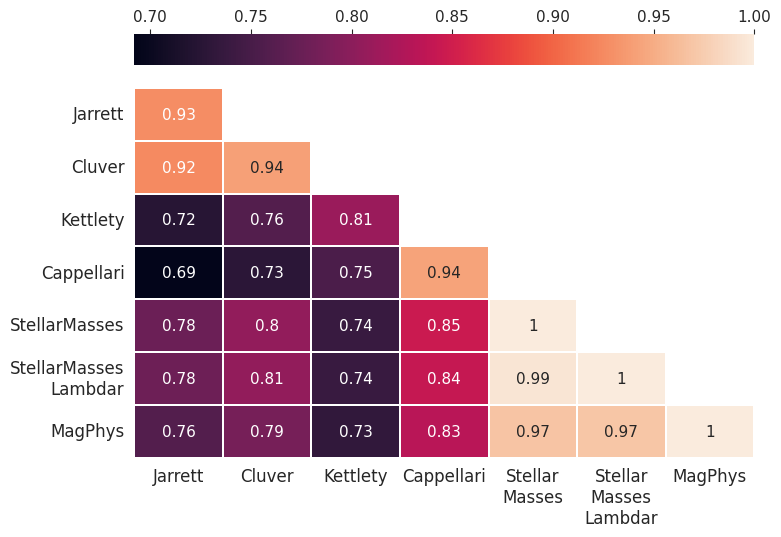

In [16]:
# Heatmap of the correlations
names_y = [ 'Jarrett', 'Cluver', 'Kettlety', 'Cappellari', 'StellarMasses', 'StellarMasses\nLambdar', 'MagPhys' ]
names_x = [ 'Jarrett', 'Cluver', 'Kettlety', 'Cappellari', 'Stellar\nMasses', 'Stellar\nMasses\nLambdar', 'MagPhys' ]
fig = plt.figure( figsize = (8,6), dpi = 100 )
mask = np.triu(np.ones_like( ccorr, dtype=bool ))
np.fill_diagonal( mask, False )
dataplot = sns.heatmap( ccorr, annot = True, fmt = '.2g', annot_kws=dict(fontsize = 11),
                       linewidth=.1, mask = mask,
                       cbar_kws = dict(use_gridspec=False,location="top"),
                       xticklabels = names_x, yticklabels = names_y )
dataplot.tick_params(left=False, bottom=False)
dataplot.set_xticklabels( dataplot.get_xmajorticklabels(), fontsize = 12 )
dataplot.set_yticklabels( dataplot.get_ymajorticklabels(), fontsize = 12 )
cbar = dataplot.collections[0].colorbar
cbar.ax.tick_params(labelsize = 11)
plt.xticks(rotation=0) 
plt.savefig( 'correlations_pearson.eps', format = 'eps', dpi = 100, bbox_inches='tight' )
plt.show() 

#### Root mean square error in log space

$$D = \sqrt{\frac{1}{N} \sum\limits_{i} (x_i-m_i)^2},$$
where $x_i$ and $m_i$ are log stellar masses.

In [17]:
def D( x, m ):
    return np.sqrt(np.mean((x-m)**2)) 

In [23]:
print( 'With StellarMasses:' )
print( 'Jarrett:', D( to_corr.Jarrett, to_corr.GAMA ) )
print( 'Cluver:', D( to_corr.Cluver, to_corr.GAMA ) )
print( 'Kettlety:', D( to_corr.Kettlety, to_corr.GAMA ) )
print( 'Cappellari:', D( to_corr.Cappellari, to_corr.GAMA ) )

With StellarMasses:
Jarrett: 0.44278244927193605
Cluver: 0.26229273539590864
Kettlety: 0.2590318615608165
Cappellari: 0.47309819111562684


In [24]:
print( 'With StellarMassesLambdar:' )
print( 'Jarrett:', D( to_corr.Jarrett, to_corr.LAMBDAR ) )
print( 'Cluver:', D( to_corr.Cluver, to_corr.LAMBDAR ) )
print( 'Kettlety:', D( to_corr.Kettlety, to_corr.LAMBDAR ) )
print( 'Cappellari:', D( to_corr.Cappellari, to_corr.LAMBDAR ) )

With StellarMassesLambdar:
Jarrett: 0.45915637776268187
Cluver: 0.2748828823103717
Kettlety: 0.2745073651475909
Cappellari: 0.46022501434528595


In [25]:
print( 'With MagPhys:' )
print( 'Jarrett:', D( to_corr.Jarrett, to_corr.MAGPHYS ) )
print( 'Cluver:', D( to_corr.Cluver, to_corr.MAGPHYS ) )
print( 'Kettlety:', D( to_corr.Kettlety, to_corr.MAGPHYS ) )
print( 'Cappellari:', D( to_corr.Cappellari, to_corr.MAGPHYS ) )

With MagPhys:
Jarrett: 0.43032909240776324
Cluver: 0.27002135420835205
Kettlety: 0.25529747681296155
Cappellari: 0.5119771456494456


In [27]:
print('means:')
print( 'Jarrett:', np.mean(( D( to_corr.Jarrett, to_corr.GAMA ), D(to_corr.Jarrett, to_corr.LAMBDAR), D( to_corr.Jarrett, to_corr.MAGPHYS ) )) )
print( 'Cluver:', np.mean(( D( to_corr.Cluver, to_corr.GAMA ), D(to_corr.Cluver, to_corr.LAMBDAR), D( to_corr.Cluver, to_corr.MAGPHYS ) )) )
print( 'Kettlety:', np.mean(( D( to_corr.Kettlety, to_corr.GAMA ), D(to_corr.Kettlety, to_corr.LAMBDAR), D( to_corr.Kettlety, to_corr.MAGPHYS ) )) )
print( 'Cappellari:', np.mean(( D( to_corr.Cappellari, to_corr.GAMA ), D(to_corr.Cappellari, to_corr.LAMBDAR), D( to_corr.Cappellari, to_corr.MAGPHYS ) )) )

means:
Jarrett: 0.44408930648079376
Cluver: 0.26906565730487747
Kettlety: 0.2629455678404563
Cappellari: 0.4817667837034529
